In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [10]:
import sys
print(sys.executable)

C:\ProgramData\miniconda3\python.exe


In [11]:
from scipy.stats import linregress
print("SciPy installed successfully!")

SciPy installed successfully!


In [12]:
import sys
print(sys.executable)

C:\ProgramData\miniconda3\python.exe


In [14]:

from scipy.stats import linregress

In [15]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

fund = pd.read_csv("../data/raw/01_fund_master.csv")

In [16]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

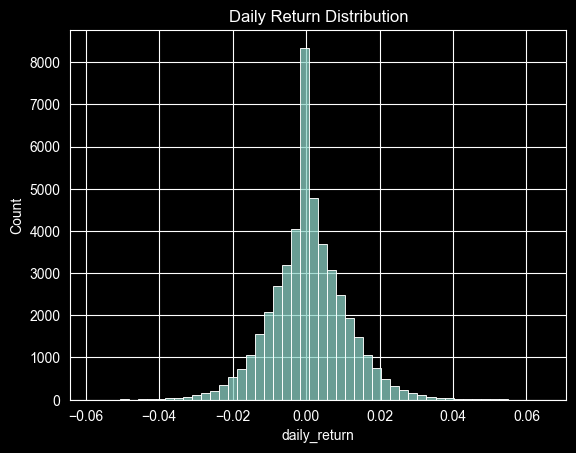

In [17]:
sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Daily Return Distribution")
plt.show()

In [18]:
cagr_table = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]

    years = (
        (df["date"].max() -
         df["date"].min()).days
    ) / 365

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
    ) - 1

    cagr_table.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_table,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

In [19]:
rf = 0.065

sharpe = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .apply(
           lambda x:
           ((x.mean()-rf/252)
            /x.std())
            * np.sqrt(252)
       )
)

In [20]:
def sortino_ratio(x):

    downside = x[x < 0]

    return (
        (x.mean()-0.065/252)
        /
        downside.std()
    ) * np.sqrt(252)

sortino = (
    nav.groupby("amfi_code")
       ["daily_return"]
       .apply(sortino_ratio)
)

In [21]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["benchmark_return"] = (
    benchmark["index_value"]
    .pct_change()
)

KeyError: 'index_value'

In [22]:
print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


In [23]:
print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [24]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [25]:
print(benchmark[[
    "date",
    "close_value",
    "benchmark_return"
]].head())

        date  close_value  benchmark_return
0 2022-01-03     17492.79               NaN
1 2022-01-04     17689.64          0.011253
2 2022-01-05     17835.05          0.008220
3 2022-01-06     17878.51          0.002437
4 2022-01-07     17759.15         -0.006676


In [26]:
import sys
print(sys.executable)

C:\ProgramData\miniconda3\python.exe


In [27]:
from scipy.stats import linregress

print("SciPy installed successfully!")

SciPy installed successfully!


In [28]:
benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

In [29]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [33]:
from scipy.stats import linregress

print("SciPy installed successfully!")

SciPy installed successfully!


In [38]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [39]:
print(alpha_beta_df.shape)
alpha_beta_df.head()

(40, 3)


,amfi_code,alpha,beta
0,100016,0.035008,0.004843
1,100025,0.043330,-0.003422
2,100033,0.268752,0.024097
3,101206,0.214656,-0.000067
4,101207,0.110250,-0.023588


In [40]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [41]:
def max_drawdown(df):

    roll_max = (
        df["nav"]
        .cummax()
    )

    drawdown = (
        df["nav"] -
        roll_max
    ) / roll_max

    return drawdown.min()

mdd = (
    nav.groupby("amfi_code")
       .apply(max_drawdown)
)

In [42]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

NameError: name 'scorecard' is not defined

In [44]:
plt.figure(figsize=(12,6))

# plot top 5 funds

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 1200x600 with 0 Axes>

In [45]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '_pydevd_bundle', '_i', '_ii', '_iii', '_i1', 'pd', '_i2', 'np', '_i3', 'plt', '_i4', 'sns', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', 'sys', '_i11', 'linregress', '_i12', '_i13', '_i14', '_i15', 'nav', 'benchmark', 'performance', 'fund', '_i16', '_i17', '_i18', 'cagr_table', 'code', 'df', 'start_nav', 'end_nav', 'years', 'cagr', 'cagr_df', '_i19', 'rf', 'sharpe', '_i20', 'sortino_ratio', 'sortino', '_i21', '_i22', '_i23', '_i24', '_24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', 'alpha_beta', 'merged', 'slope', 'intercept', 'r', 'p', 'se', 'alpha', 'beta', 'alpha_beta_df', '_37', '_i38', '_38', '_i39', '_39', '_i40', '_i41', 'max_drawdown', 'mdd', '_i42', '_i43', '_i44', '_i45'])


In [46]:
print(cagr_df.head())
print(alpha_beta_df.head())

   amfi_code      cagr
0     100016  0.026352
1     100025  0.044551
2     100033  0.300997
3     101206  0.235205
4     101207  0.079331
   amfi_code     alpha      beta
0     100016  0.035008  0.004843
1     100025  0.043330 -0.003422
2     100033  0.268752  0.024097
3     101206  0.214656 -0.000067
4     101207  0.110250 -0.023588


In [47]:
print(type(sharpe))
print(type(sortino))
print(type(mdd))

<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>


In [48]:
scorecard = cagr_df.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

scorecard["sharpe"] = sharpe.values
scorecard["sortino"] = sortino.values
scorecard["max_drawdown"] = mdd.values

scorecard.head()

,amfi_code,cagr,alpha,beta,sharpe,sortino,max_drawdown
0,100016,0.026352,0.035008,0.004843,-0.201517,-0.351047,-0.247344
1,100025,0.044551,0.043330,-0.003422,-0.567095,-0.941821,-0.043083
2,100033,0.300997,0.268752,0.024097,1.093699,1.829134,-0.162172
3,101206,0.235205,0.214656,-0.000067,1.027213,1.799563,-0.112916
4,101207,0.079331,0.110250,-0.023588,0.162661,0.276644,-0.354469


In [49]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(ascending=False)

scorecard["sortino_rank"] = scorecard["sortino"].rank(ascending=False)

scorecard["sharpe_rank"] = scorecard["sharpe"].rank(ascending=False)

scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

scorecard["mdd_rank"] = scorecard["max_drawdown"].rank(ascending=True)

In [50]:
scorecard["fund_score"] = (
    0.30 * scorecard["cagr_rank"] +
    0.25 * scorecard["sortino_rank"] +
    0.20 * scorecard["sharpe_rank"] +
    0.15 * scorecard["alpha_rank"] +
    0.10 * scorecard["mdd_rank"]
)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr,alpha,beta,sharpe,sortino,max_drawdown,cagr_rank,sortino_rank,sharpe_rank,alpha_rank,mdd_rank,fund_score
25,120505,0.328016,0.295085,-0.017454,1.180101,2.029353,-0.181885,1.0,5.0,5.0,3.0,16.0,4.60
36,148569,0.319245,0.280803,0.017641,1.234930,2.146914,-0.163967,4.0,3.0,3.0,4.0,20.0,5.15
34,148567,0.309499,0.269107,0.010472,1.448291,2.385644,-0.112657,5.0,1.0,1.0,6.0,33.0,6.15
30,120843,0.308833,0.273211,-0.004370,1.306744,2.364320,-0.129740,6.0,2.0,2.0,5.0,28.0,6.25
21,119598,0.323981,0.303145,-0.003508,0.945308,1.675317,-0.287060,2.0,12.0,14.0,1.0,5.0,7.05
39,149324,0.322621,0.295821,0.036667,0.949796,1.619793,-0.311719,3.0,14.0,13.0,2.0,4.0,7.70
38,149323,0.295581,0.265733,0.001259,1.132122,1.875101,-0.172481,8.0,6.0,6.0,8.0,19.0,8.20
2,100033,0.300997,0.268752,0.024097,1.093699,1.829134,-0.162172,7.0,8.0,7.0,7.0,21.0,8.65
19,119551,0.257849,0.234544,-0.025189,1.208267,2.140267,-0.150124,10.0,4.0,4.0,10.0,24.0,8.70
9,118632,0.240312,0.215785,0.016157,1.081659,1.850133,-0.174141,11.0,7.0,8.0,12.0,18.0,10.25


In [51]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund scorecard saved successfully!")

Fund scorecard saved successfully!


In [52]:
import os

print(
    os.path.exists(
        "../data/processed/fund_scorecard.csv"
    )
)

True


In [53]:
# Create Scorecard DataFrame

scorecard = cagr_df.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left"
)

# Add Sharpe Ratio
scorecard["sharpe"] = sharpe.values

# Add Sortino Ratio
scorecard["sortino"] = sortino.values

# Add Maximum Drawdown
scorecard["max_drawdown"] = mdd.values

# Rankings

scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sortino_rank"] = scorecard["sortino"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe"].rank(
    ascending=False
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False
)

scorecard["mdd_rank"] = scorecard["max_drawdown"].rank(
    ascending=True
)

# Composite Fund Score

scorecard["fund_score"] = (
    0.30 * scorecard["cagr_rank"] +
    0.25 * scorecard["sortino_rank"] +
    0.20 * scorecard["sharpe_rank"] +
    0.15 * scorecard["alpha_rank"] +
    0.10 * scorecard["mdd_rank"]
)

# Sort Best Funds First

scorecard = scorecard.sort_values(
    "fund_score"
)

# Display Top 10 Funds

print(scorecard.head(10))

# Save CSV

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully!")

    amfi_code      cagr     alpha      beta    sharpe   sortino  max_drawdown  \
25     120505  0.328016  0.295085 -0.017454  1.180101  2.029353     -0.181885   
36     148569  0.319245  0.280803  0.017641  1.234930  2.146914     -0.163967   
34     148567  0.309499  0.269107  0.010472  1.448291  2.385644     -0.112657   
30     120843  0.308833  0.273211 -0.004370  1.306744  2.364320     -0.129740   
21     119598  0.323981  0.303145 -0.003508  0.945308  1.675317     -0.287060   
39     149324  0.322621  0.295821  0.036667  0.949796  1.619793     -0.311719   
38     149323  0.295581  0.265733  0.001259  1.132122  1.875101     -0.172481   
2      100033  0.300997  0.268752  0.024097  1.093699  1.829134     -0.162172   
19     119551  0.257849  0.234544 -0.025189  1.208267  2.140267     -0.150124   
9      118632  0.240312  0.215785  0.016157  1.081659  1.850133     -0.174141   

    cagr_rank  sortino_rank  sharpe_rank  alpha_rank  mdd_rank  fund_score  
25        1.0           5.0    

In [54]:
scorecard.head()

,amfi_code,cagr,alpha,beta,sharpe,sortino,max_drawdown,cagr_rank,sortino_rank,sharpe_rank,alpha_rank,mdd_rank,fund_score
25,120505,0.328016,0.295085,-0.017454,1.180101,2.029353,-0.181885,1.0,5.0,5.0,3.0,16.0,4.60
36,148569,0.319245,0.280803,0.017641,1.234930,2.146914,-0.163967,4.0,3.0,3.0,4.0,20.0,5.15
34,148567,0.309499,0.269107,0.010472,1.448291,2.385644,-0.112657,5.0,1.0,1.0,6.0,33.0,6.15
30,120843,0.308833,0.273211,-0.004370,1.306744,2.364320,-0.129740,6.0,2.0,2.0,5.0,28.0,6.25
21,119598,0.323981,0.303145,-0.003508,0.945308,1.675317,-0.287060,2.0,12.0,14.0,1.0,5.0,7.05


In [55]:
import os

print(
    os.path.exists(
        "../data/processed/fund_scorecard.csv"
    )
)

True


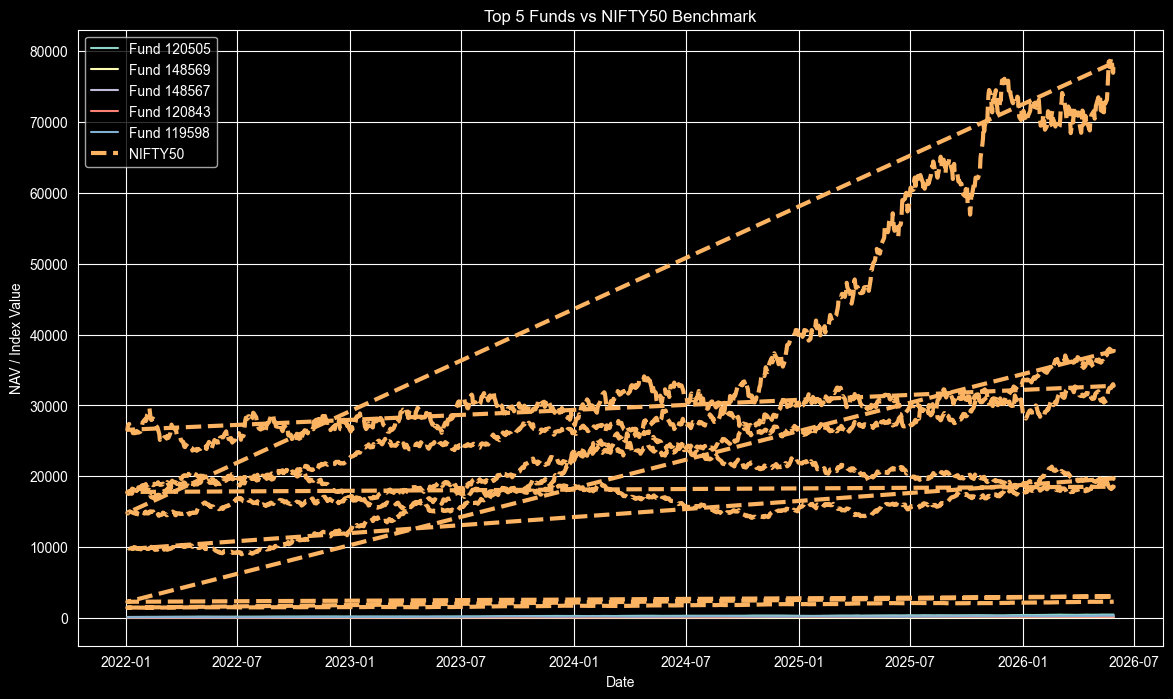

In [56]:
import matplotlib.pyplot as plt
import pandas as pd

# Top 5 funds from scorecard

top5 = scorecard.head(5)["amfi_code"].tolist()

# Filter NAV data

top_nav = nav[
    nav["amfi_code"].isin(top5)
].copy()

top_nav["date"] = pd.to_datetime(
    top_nav["date"]
)

# Benchmark

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Plot

plt.figure(figsize=(14,8))

for code in top5:

    df = top_nav[
        top_nav["amfi_code"] == code
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=f"Fund {code}"
    )

# Benchmark line

plt.plot(
    benchmark["date"],
    benchmark["close_value"],
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

plt.title(
    "Top 5 Funds vs NIFTY50 Benchmark"
)

plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [57]:
import os

print(
    os.path.exists(
        "../reports/benchmark_comparison.png"
    )
)

True
